$Q3)$

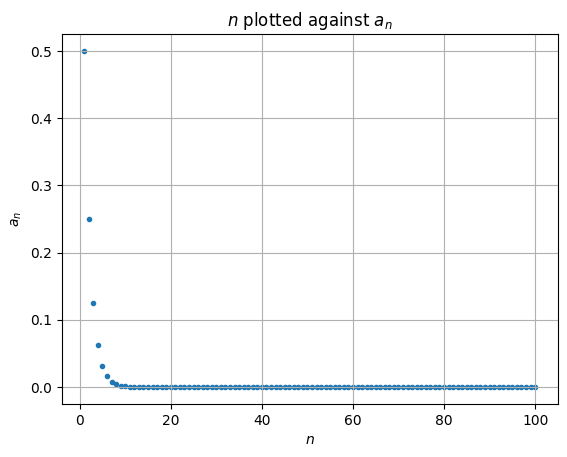

The order of convergence of 2^-n is 1.


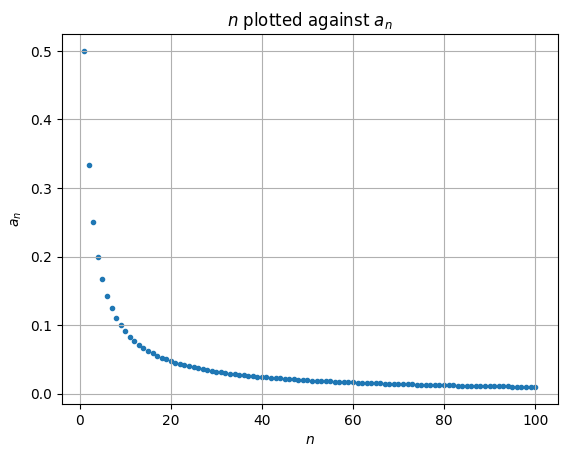

The order of convergence of 1/(n+1) is 1.


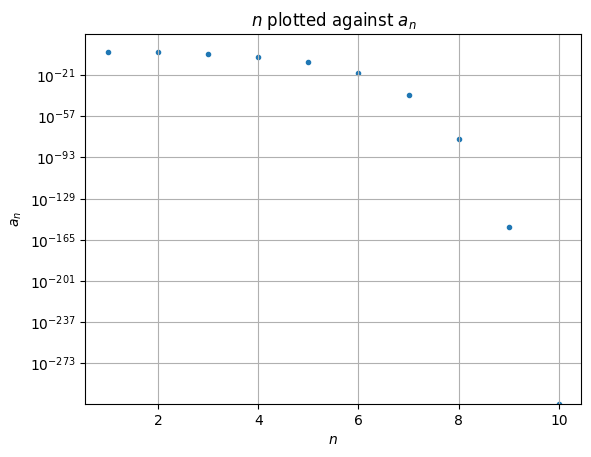

The order of convergence of 2**-(2^n) is 2.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
n=sp.Symbol("n") #note we must let n be complex otherwise the programme simply errors saying the limit vaires depending on whether the o >,=,< order of the sequence.
o=sp.Symbol("o",positive=True)
def plot_fn(a_n,N,scale='linear'):
    vec_a_n=np.vectorize(lambda n_x :a_n.subs({n:n_x})) #so that we can sub n into a_n for all values concurrently
    xs=np.linspace(1,N,N) #produces a numpy array of all integers 1 to N
    ys=vec_a_n(xs) # produces an associated array with an for all values in xs
    plt.grid()
    plt.scatter(xs,ys,marker='.')
    plt.yscale(scale)
    plt.xlabel(r"$n$")
    plt.ylabel(r"$a_n$")
    plt.title(r"$n$ plotted against $a_n$")
    plt.gcf().set_dpi(100)
    plt.show()
    #plots the graph
def order_of_convergence(a_n):
    L_a_n=sp.limit_seq(a_n,n) #true value of limit of a_n
    ln_rate=sp.sign(sp.limit(sp.log(sp.Abs(((L_a_n-a_n.subs({n:n+1}))**o)/(L_a_n-a_n))),n,sp.oo))
    #ln of standard expression for rate based on order. Need ln to stop sympy over simplifying down to always equalling oo as it's a complex limit. sp.sign removes the infinity which means we can apply the solve function.
    reciprical_order_set=sp.simplify(sp.solveset(ln_rate,o,domain= sp.S.Reals))
    #makes sure to remind the programme it's real otherwise it doesn't fully simplify asit wants to store the underlying representation of my limit is a complex limit.
    for reciprical_order in reciprical_order_set:
        return (1/reciprical_order)
plot_fn(2**(-n),100)
print(f'The order of convergence of 2^-n is {order_of_convergence(2**(-n))}.')
plot_fn((n+1)**(-1),100)
print(f'The order of convergence of 1/(n+1) is {order_of_convergence((n+1)**(-1))}.')
plot_fn(2**(-(2**n)),10,'log')
print(f'The order of convergence of 2**-(2^n) is {order_of_convergence(2**(-(2**n)))}.')


$Q4)$

In [7]:
x=sp.Symbol("x")
def is_banach_contraction(g,X): #assumes continuous domain
    if not(X==sp.Interval(X.inf,X.sup)): # checks for continuity of domain 
        return "Domain Error enter a Continuous Domain."
    elif not(sp.calculus.util.continuous_domain(g,x,X)==X): #checks the function is continuous
        return False
    elif not(sp.calculus.util.function_range(g,x,X).is_subset(X)): #checks it is an endomorphism
        return False
    elif not(sp.calculus.util.function_range(sp.diff(g,x),x,X.interior).is_proper_subset(sp.Interval.open(-1,1))): #checks that the derivative stays in a closed interval bounded away from 1
        return False
    else:
        return True
print("input the function")
g=eval(input())
while g!=False:#allows inputting values
    print("input set, as min return max.")
    X=sp.Interval(eval(input()),eval(input()))
    print(f"{g} has Banach's contraction theorem apply over set {X} is {is_banach_contraction(g,X)}")
    print("input the function")
    g=eval(input())

input the function
input set, as min return max.
x + sin(x) has Banach's contraction theorem apply over set Interval(3*pi/4, 5*pi/4) is True
input the function
input set, as min return max.
x**3 + 3*x**2 - 3 has Banach's contraction theorem apply over set Interval(0, 2) is False
input the function
input set, as min return max.
x + 1/x has Banach's contraction theorem apply over set Interval(1, oo) is True
input the function


$Q5a)$

In [38]:
logM=sp.Symbol("logM")
q=sp.Symbol("q")
print("input e_n,e_n+1,e_n+2")
e=eval("["+input()+"]")
print(e)
def find_M_q(e):
    sol=sp.linsolve([-sp.log(e[1])+logM+q*sp.log(e[0]),-sp.log(e[2])+logM+q*sp.log(e[1])],logM,q)
    #solve log of both sides as then can have sympy solve using linear equation solver
    return [sol.args[0][1],sp.exp(sol.args[0][0])]#args takes solution out of the set 
print(f'q={find_M_q(e)[0]}. M={find_M_q(e)[1]}.') 

input e_n,e_n+1,e_n+2
[2, 0.5, 2]
q=-1.00000000000000. M=1.00000000000000.


$Q5b)$

In [18]:
k=sp.Symbol('k')
def Leibniz (n,evalf=True):
    if n%2==0:
        sum=4*(sp.Sum((1/(4*k+1))-(1/(4*k+3)),(k,0,((n-1)/2)))+1/(2*n+1)) # adds 2 terms at once to avoid unnecessary exponentiation
    else:
        sum=4*(sp.Sum((1/(4*k+1))-(1/(4*k+3)),(k,0,-0.5+(n/2)))) # adds 2 terms at once to avoid unnecessary exponentiation
    if evalf==True:
        return sum.evalf() #turns in to a numeric value for efficiency
    else:
        return sum
e=[sp.Abs(sp.pi-Leibniz(10000)),sp.Abs(sp.pi-Leibniz(10001)),sp.Abs(sp.pi-Leibniz(10002))]
print(e)
print(f'q={find_M_q(e)[0].evalf()}. M={find_M_q(e)[1].evalf()}.')
print("As q really small so order is approximately 0.")

[3.14169265358954 - pi, -3.14149267358604 + pi, 3.14169263359354 - pi]
q=1.22501427962385E-8. M=0.0000999800150299991.
As q really small so order is approximately 0.


$Q5c)$

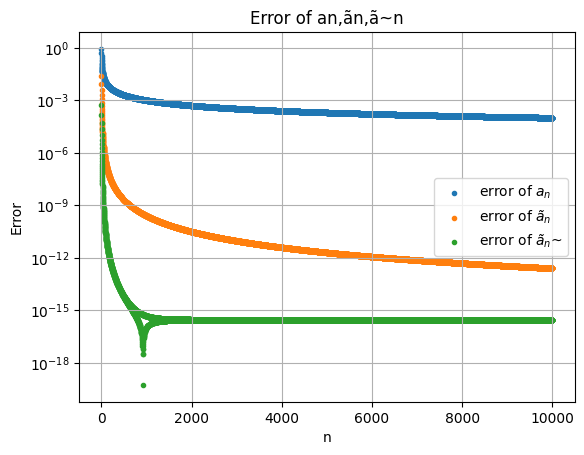

In [39]:
import mpmath
mpmath.mp.dps=1000
def np_Leibniz(n): #reimplement leibniz in numpy
    if n%2==0:
        a_n[n]=a_n[n-1]+4/(2*n+1)
    else:
        a_n[n]=a_n[n-1]-4/(2*n+1)
def error(a_n): # allows us to calculate error and vectorises well
    return(np.abs(a_n-np.pi))
vec_error=np.vectorize(error)
def Aitken(n,a_n): #runs Aitken on any function. so we can make functions on one vectorised variable. (note we can't directly use the vectorised version of this as one of the inputs is a nonstring, nonfloat)
    return a_n[int(n)]-((a_n[int(n+1)]-a_n[int(n)])**2)/(a_n[int(n+2)]-2*a_n[int(n+1)]+a_n[int(n)])
def a_n_Aitken (n): #makes a nice vectorised function
    return Aitken(n,a_n)
def ã_n_Aitken (n): #makes a nice vectorised function
    return Aitken(n,Aitken_1_a_n)
vec_ã_n_aitken=np.vectorize(ã_n_Aitken)
vec_a_n_aitken=np.vectorize(a_n_Aitken)
xs=np.linspace(0,10006,10007) #to generate an x axis that is too long by the minimum to aitken it twice and stay above 10000 terms
a_n=np.linspace(mpmath.mpf(0),mpmath.mpf(10006),10007) #var for a_n
error_Aitken_a_n=np.linspace(mpmath.mpf(0),mpmath.mpf(10003),10004) #var that eventually becomes the error after one iteration of Aitken
error_Aitken_ã_n=np.linspace(mpmath.mpf(0),mpmath.mpf(10000),10001) #var that eventually becomes the error after two iterations of Aitken
a_n[0]=mpmath.mpf(4)
for i in range(1,len(xs)): #generates a_n
    np_Leibniz(i)
e_n=vec_error(a_n)
Aitken_1_a_n=vec_a_n_aitken(error_Aitken_a_n)
error_Aitken_a_n=vec_error(vec_a_n_aitken(error_Aitken_a_n))
error_Aitken_ã_n=vec_error(vec_ã_n_aitken(error_Aitken_ã_n)) #calculates all the Aitken iterations
xs=xs[0:10001] #chop off any vectors that are too long
e_n=e_n[0:10001]
error_Aitken_a_n=error_Aitken_a_n[0:10001]
error_Aitken_ã_n=error_Aitken_ã_n[0:10001]
plt.grid()
plt.scatter(xs, e_n,label="error of $a_n$",marker=".")
plt.scatter(xs, error_Aitken_a_n,label="error of $ã_n$",marker=".")
plt.scatter(xs, error_Aitken_ã_n,label="error of $ã_n$~",marker=".")#  note lack of fast convergence due to nonlinear ãn convergence
plt.ylabel(r"Error")
plt.xlabel(r"n")
plt.yscale('log')
plt.title(r"Error of an,ãn,ã~n")
plt.legend()
plt.gcf().set_dpi(100)
plt.show()

$Q5d)$

In [40]:
error_Aitken_a_n=[error_Aitken_a_n[9998],error_Aitken_a_n[9999],error_Aitken_a_n[10000]]
print(f'For ãn: q={find_M_q(error_Aitken_a_n)[0].evalf()}. M={find_M_q(error_Aitken_a_n)[1].evalf()}.')
print('As q is a negative answer>-1 ãn has a sublinear of convergence and it is alternating on increasing/decreasing error.')
error_Aitken_ã_n=[error_Aitken_ã_n[9998],error_Aitken_ã_n[9999],error_Aitken_ã_n[10000]]
print(f'For ã~n: q={find_M_q(error_Aitken_ã_n)[0].evalf()}. M={find_M_q(error_Aitken_ã_n)[1].evalf()}.')
print('As q is a negative answer <-1  ã~n has a superlinear order of convergence with alternating better and worse estimates.')

For ãn: q=-0.770003099301171. M=4.94388864832958E-23.
As q is a negative answer>-1 ãn has a sublinear of convergence and it is alternating on increasing/decreasing error.
For ã~n: q=-1.66442850894968. M=3.92382882277591E-42.
As q is a negative answer <-1  ã~n has a superlinear order of convergence with alternating better and worse estimates.
